In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [13]:
df = pd.read_csv("car_price_prediction_.csv")

In [14]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB


In [18]:
df.count()

Car ID          2500
Brand           2500
Year            2500
Engine Size     2500
Fuel Type       2500
Transmission    2500
Mileage         2500
Condition       2500
Price           2500
Model           2500
dtype: int64

In [19]:
df.isnull().sum()

Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64

In [20]:
df.describe()

,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


In [26]:
df["Brand"].unique()

array(['Tesla', 'BMW', 'Audi', 'Ford', 'Honda', 'Mercedes', 'Toyota'],
      dtype=object)

In [30]:
df["Brand"].value_counts()

Brand
Toyota      374
Audi        368
BMW         358
Mercedes    353
Honda       352
Tesla       348
Ford        347
Name: count, dtype: int64

In [32]:
df["Fuel Type"].value_counts()

Fuel Type
Diesel      655
Petrol      630
Electric    614
Hybrid      601
Name: count, dtype: int64

In [33]:
df["Transmission"].value_counts()

Transmission
Manual       1308
Automatic    1192
Name: count, dtype: int64

In [37]:
df.groupby("Brand")["Price"].mean().sort_values(ascending=False)

Brand
BMW         54157.114385
Tesla       53475.547471
Mercedes    53191.090085
Toyota      52078.728235
Honda       52050.283949
Audi        51953.424810
Ford        51593.254813
Name: Price, dtype: float64

In [61]:
df[(df['Year'] >= 2020) & (df['Mileage'] <= 50000)]

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
21,22,Mercedes,2022,2.3,Electric,Manual,12150,Used,61393.26,E-Class
74,75,Tesla,2020,3.9,Petrol,Manual,30531,New,14812.88,Model S
90,91,Honda,2022,5.1,Diesel,Automatic,29882,Used,57189.63,CR-V
243,244,Toyota,2022,4.3,Electric,Manual,20092,New,45216.96,Prius
264,265,Audi,2021,1.8,Electric,Automatic,8328,New,38018.04,A3
...,...,...,...,...,...,...,...,...,...,...
2444,2445,Honda,2022,5.3,Petrol,Manual,19416,New,80286.31,Civic
2448,2449,Honda,2021,5.0,Petrol,Automatic,64,New,29641.48,Accord
2481,2482,BMW,2022,1.7,Petrol,Automatic,28004,New,74883.99,3 Series
2487,2488,Audi,2021,4.6,Electric,Automatic,9466,Used,15126.76,A3


In [64]:
year_2020 = df[(df['Year'] >= 2020) & (df['Mileage'] <= 50000)]

In [65]:
year_2020.groupby("Brand")["Price"].mean().sort_values(ascending=False)

Brand
BMW         66726.669231
Ford        57006.723333
Audi        53971.783333
Mercedes    51416.939091
Tesla       51248.373000
Honda       51141.774167
Toyota      45756.606429
Name: Price, dtype: float64

In [67]:
df["Transmission"].unique()

array(['Manual', 'Automatic'], dtype=object)

In [72]:
df['Transmission'] = df['Transmission'].replace({
    'Manual': 0,
    'Automatic': 1
})

C:\Users\kursa\AppData\Local\Temp\ipykernel_20972\460591943.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Transmission'] = df['Transmission'].replace({


In [73]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,0,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,0,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,0,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,1,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,0,223009,Like New,73577.10,Mustang


In [74]:
df["Condition"].unique()

array(['New', 'Used', 'Like New'], dtype=object)

In [75]:
df['Condition'] = df['Condition'].replace({
    'Used': 0,
    'New': 1,
    'Like New': 2
})

C:\Users\kursa\AppData\Local\Temp\ipykernel_20972\1705812146.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Condition'] = df['Condition'].replace({


In [76]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,0,114832,1,26613.92,Model X
1,2,BMW,2018,4.4,Electric,0,143190,0,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,0,181601,1,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,1,68682,1,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,0,223009,2,73577.10,Mustang


In [77]:
corelation = df.corr(numeric_only=True)

In [78]:
corelation

,Car ID,Year,Engine Size,Transmission,Mileage,Condition,Price
Car ID,1.000000,0.008050,0.000059,-0.033872,-0.035840,0.038329,0.004650
Year,0.008050,1.000000,0.011833,0.013961,0.002282,-0.007243,-0.036805
Engine Size,0.000059,0.011833,1.000000,0.004885,-0.015782,-0.011435,-0.004420
Transmission,-0.033872,0.013961,0.004885,1.000000,0.024265,-0.008707,0.001877
Mileage,-0.035840,0.002282,-0.015782,0.024265,1.000000,0.015849,-0.008567
Condition,0.038329,-0.007243,-0.011435,-0.008707,0.015849,1.000000,0.015669
Price,0.004650,-0.036805,-0.004420,0.001877,-0.008567,0.015669,1.000000


<Axes: >

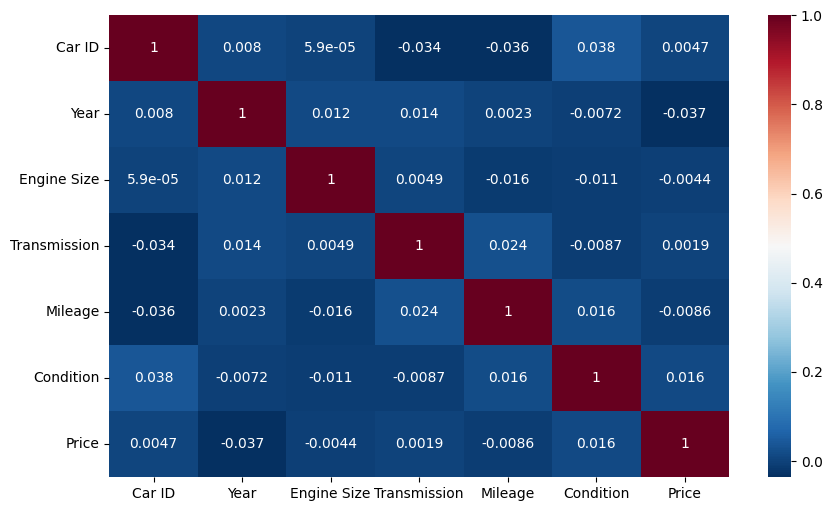

In [85]:
plt.figure(figsize=(10,6))
sns.heatmap(corelation,annot=True,cmap='RdBu_r')      

In [113]:
df["Fuel Type"].unique()

array([1, 3, 0, 2])

In [114]:
df['Fuel Type'] = df['Fuel Type'].replace({
    'Petrol': 1,
    'Diesel': 0,
    'Hybrid': 2,
    'Electric': 3,
})

In [115]:
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,1,0,114832,1,26613.92,Model X
1,2,BMW,2018,4.4,3,0,143190,0,14679.61,5 Series
2,3,Audi,2013,4.5,3,0,181601,1,44402.61,A4
3,4,Tesla,2011,4.1,0,1,68682,1,86374.33,Model Y
4,5,Ford,2009,2.6,0,0,223009,2,73577.10,Mustang


In [165]:
X = df.iloc[:,2:-2]  # year engine size fuel type transmission mileage condition price 
y = df["Price"]

In [123]:
X.head()

,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition
0,2016,2.3,1,0,114832,1
1,2018,4.4,3,0,143190,0
2,2013,4.5,3,0,181601,1
3,2011,4.1,0,1,68682,1
4,2009,2.6,0,0,223009,2


In [121]:
y.head()

0    26613.92
1    14679.61
2    44402.61
3    86374.33
4    73577.10
Name: Price, dtype: float64

In [124]:
from sklearn.model_selection import train_test_split

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25, random_state=35)

In [126]:
from sklearn.preprocessing import StandardScaler

In [127]:
scaler = StandardScaler()

In [128]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [131]:
from sklearn.linear_model import LinearRegression

In [132]:
regression = LinearRegression()

In [134]:
regression.fit(X_train, y_train)  # En uygun katsayıları (β) X_train (bağımsız değişkenler) ile
#y_train (bağımlı değişken) arasındaki ilişkiyi öğrenir
# En uygun sabit terimi (intercept) hesaplar

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [138]:
X_test[0]

array([-0.65990765,  0.02112826, -0.40899394, -0.95667111,  1.61297612,
       -1.19331949])

In [140]:
X.iloc[0]

Year              2016.0
Engine Size          2.3
Fuel Type            1.0
Transmission         0.0
Mileage         114832.0
Condition            1.0
Name: 0, dtype: float64

In [162]:
new_car1 = [[2006,2.5,3,1,50000,2]]  #2021 year // 2.5 engine //  3= electric // 1= automatic // 70.000 miles // condination 1 

In [163]:
new_car_scaled = scaler.transform(new_car1)

C:\Users\kursa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [164]:
regression.predict(new_car_scaled) #50.960 olarak fiyatı tahmin etti

array([52630.165577])

## PREDİCTİON PERFORMANCE

In [166]:
y_pred = regression.predict(X_test)

In [167]:
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score

In [168]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print("MSE: ", mse)
print("MAE: ", mae)

MSE:  740013292.3060988
MAE:  23592.48943456301


In [169]:
score = r2_score(y_test,y_pred)
print("r2 score:", score)

r2 score: 0.00045742014312377677


In [170]:
1 - (1-score)* (len(y_test)-1) / (len(y_test)-X_test.shape[1]-1)

-0.009246876748690402

In [ ]:
## VERİLER SALLAMASYON OLDUGUNDAN DOLAYI SONUCUMUZ ÇOK DÜŞÜK ÇIKMISTIR 